## Problem Statement

This assignment is a programming assignment wherein you have to build a multiple linear regression model for the prediction of demand for shared bikes.



### Business Goal:

You are required to model the demand for shared bikes with the available independent variables. It will be used by the management to understand how exactly the demands vary with different features. They can accordingly manipulate the business strategy to meet the demand levels and meet the customer's expectations. Further, the model will be a good way for management to understand the demand dynamics of a new market.



## Steps Involved:

1. Data Reading and Understanding
2. Data Visualisation
3. Creating Dummy Variables
4. Model building and Evaluation
5. Making Predictions
6. Final step

## 1.  Data Reading and Understanding

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import r2_score

In [3]:
# Reading dataset and looking the first five rows of the data
boombikes_data = pd.read_csv("/Volumes/Transcend/DS-41 /Module 4- ML/Mutliple linear Regression Boombikes Assignment/day.csv")
boombikes_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [4]:
# Finding out tye number of rows and columns of the data
boombikes_data.shape

(730, 16)

In [5]:
# Finding out the details of the dataset
boombikes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [6]:
# Finding out the statistical information of the data
boombikes_data.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [7]:
# Getting the columns of the data
boombikes_data.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [8]:
# percentage of missing values in each column 
round(100*(boombikes_data.isnull().sum()/len(boombikes_data)), 2).sort_values(ascending=False)

instant       0.0
dteday        0.0
season        0.0
yr            0.0
mnth          0.0
holiday       0.0
weekday       0.0
workingday    0.0
weathersit    0.0
temp          0.0
atemp         0.0
hum           0.0
windspeed     0.0
casual        0.0
registered    0.0
cnt           0.0
dtype: float64

### Data cleaning : Removing redundant & unwanted columns

##### Based on given data and the data dictionary, the following variables can be removed for further analysis
##### 1 instant : Its has only index value
##### 2 dteday : This has the date, Since we already have seperate columns for 'year' & 'month',hence its not important for our analysis
##### 3 casual & registered : Both these columns contains the count of bike booked by different categories of customers. Since our objective is to find the total count of bikes and not by specific category, we will ignore these two columns,we have created a new variable to find the ratio of these customer types.

In [9]:
Drop_boombikes_data=['instant','dteday','casual','registered']
boombikes_data.drop(labels=Drop_boombikes_data,axis=1,inplace=True)

In [10]:
boombikes_data.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [11]:
boombikes_data.shape

(730, 12)

In [12]:
# Getting data count on the basis of season
boombikes_data['season'].astype('category').value_counts()

3    188
2    184
1    180
4    178
Name: season, dtype: int64

In [13]:
## Year = 0: 2018, 1:2019
boombikes_data['yr'].value_counts()

0    365
1    365
Name: yr, dtype: int64

In [14]:
## Finding it's holiday or not =  0: No, 1: Yes
boombikes_data['holiday'].value_counts()

0    709
1     21
Name: holiday, dtype: int64

In [15]:
## Finding it's workingday or not
boombikes_data['workingday'].value_counts()

1    504
0    226
Name: workingday, dtype: int64

## 2. Data Visualisation

### Visualising Categorical Variables

Converting some numeric values to categorical data. Let's make a boxplot for these variables.

**season** : converting season values as per criteria - 1:Spring, 2:Summer, 3:Fall, 4:Winter

**mnth**: converting mnth values as 1:Jan, 2:Feb, 3:Mar, 4:Apr, 5:May, 6:Jun, 7:Jul, 8:Aug, 9:Sep, 10:Oct, 11:Nov, 12:Dec

**weathersit**: converting weathersit values as 1:Clear, 2:Misty, 3:Light_RainSnow 4:Heavy_RainSnow

**weekday**: converting weekday values as 0:Sun, 1:Mon, 2:Tue, 3:Wed, 4:Thu, 5:Fri, 6:Sat




In [16]:
boombikes_data.season.replace((1,2,3,4), ('Spring','Summer','Fall','Winter'), inplace=True)
boombikes_data.mnth.replace((1,2,3,4,5,6,7,8,9,10,11,12), ('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'), inplace=True)
boombikes_data.weathersit.replace((1,2,3,4), ('Clear','Misty','Light_rainsnow','Heavy_rainsnow'), inplace=True)
boombikes_data.weekday.replace((0,1,2,3,4,5,6), ('Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday'), inplace=True)


In [17]:
boombikes_data.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,Spring,0,Jan,0,Monday,1,Misty,14.110847,18.18125,80.5833,10.749882,985
1,Spring,0,Jan,0,Tuesday,1,Misty,14.902598,17.68695,69.6087,16.652113,801
2,Spring,0,Jan,0,Wednesday,1,Clear,8.050924,9.47025,43.7273,16.636703,1349
3,Spring,0,Jan,0,Thursday,1,Clear,8.200000,10.60610,59.0435,10.739832,1562
4,Spring,0,Jan,0,Friday,1,Clear,9.305237,11.46350,43.6957,12.522300,1600


In [18]:
boombikes_data.shape

(730, 12)

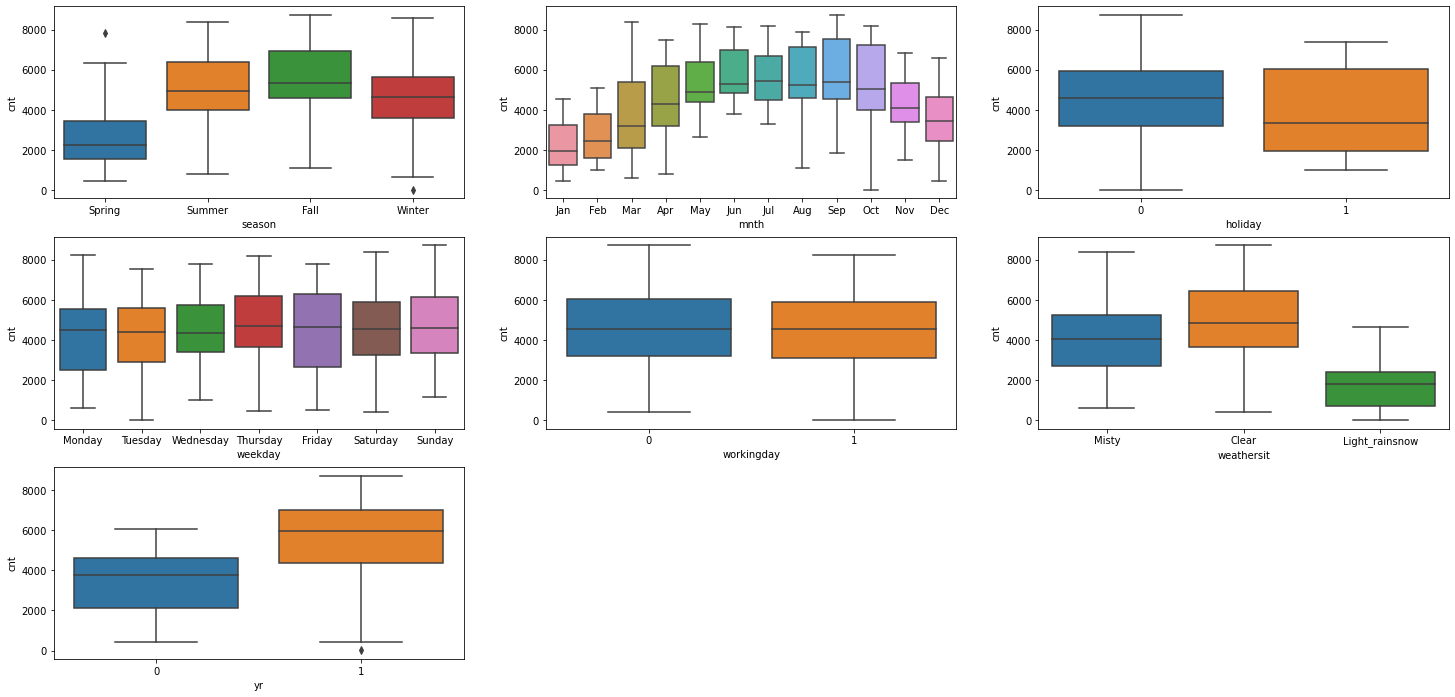

In [19]:
plt.figure(figsize=(25, 12))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'cnt', data = boombikes_data)
plt.subplot(3,3,2)
sns.boxplot(x = 'mnth', y = 'cnt', data = boombikes_data)
plt.subplot(3,3,3)
sns.boxplot(x = 'holiday', y = 'cnt', data = boombikes_data)
plt.subplot(3,3,4)
sns.boxplot(x = 'weekday', y = 'cnt', data = boombikes_data)
plt.subplot(3,3,5)
sns.boxplot(x = 'workingday', y = 'cnt', data = boombikes_data)
plt.subplot(3,3,6)
sns.boxplot(x = 'weathersit', y = 'cnt', data = boombikes_data)
plt.subplot(3,3,7)
sns.boxplot(x = 'yr', y = 'cnt', data = boombikes_data)
plt.show()

####  **Conclusion **

Bike Rentals are more during the Fall season

Bike Rentals are more in the month of september and October

Bike Rentals are more on Friday,Saturday & Sunday

Bike Rentals are more on non working days

### Visualising Numerical Variables

Visualising Numerical Variables with the help of pairplot

In [20]:
# Converting 'cnt' numeric variable to float in order to seperate out with the categorical variables 
boombikes_data['cnt'] = boombikes_data['cnt'].astype("float")

In [21]:
## Numeric data

boombikes_data_numeric = boombikes_data.select_dtypes(include=['float64'])
boombikes_data_numeric.head()

,temp,atemp,hum,windspeed,cnt
0,14.110847,18.18125,80.5833,10.749882,985.0
1,14.902598,17.68695,69.6087,16.652113,801.0
2,8.050924,9.47025,43.7273,16.636703,1349.0
3,8.200000,10.60610,59.0435,10.739832,1562.0
4,9.305237,11.46350,43.6957,12.522300,1600.0


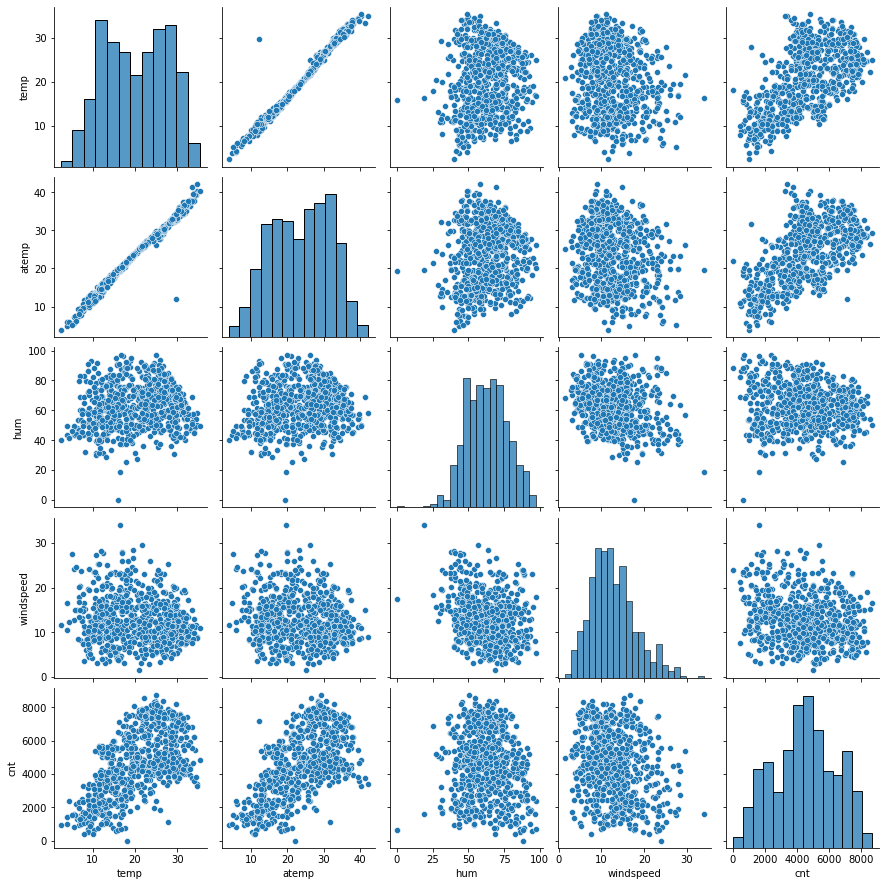

In [22]:
sns.pairplot(data=boombikes_data_numeric,vars=['temp','atemp','hum','windspeed','cnt'])
plt.show()

**Conculsion**

From the above pairplot we can see that there are some independent variables which are positively correlated to the 'cnt' variable.

For plotting multiple correlation in one plot heatmap is very useful.

In [23]:
boombikes_data_corr = boombikes_data_numeric.corr()
boombikes_data_corr

,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.991696,0.128565,-0.158186,0.627044
atemp,0.991696,1.000000,0.141512,-0.183876,0.630685
hum,0.128565,0.141512,1.000000,-0.248506,-0.098543
windspeed,-0.158186,-0.183876,-0.248506,1.000000,-0.235132
cnt,0.627044,0.630685,-0.098543,-0.235132,1.000000


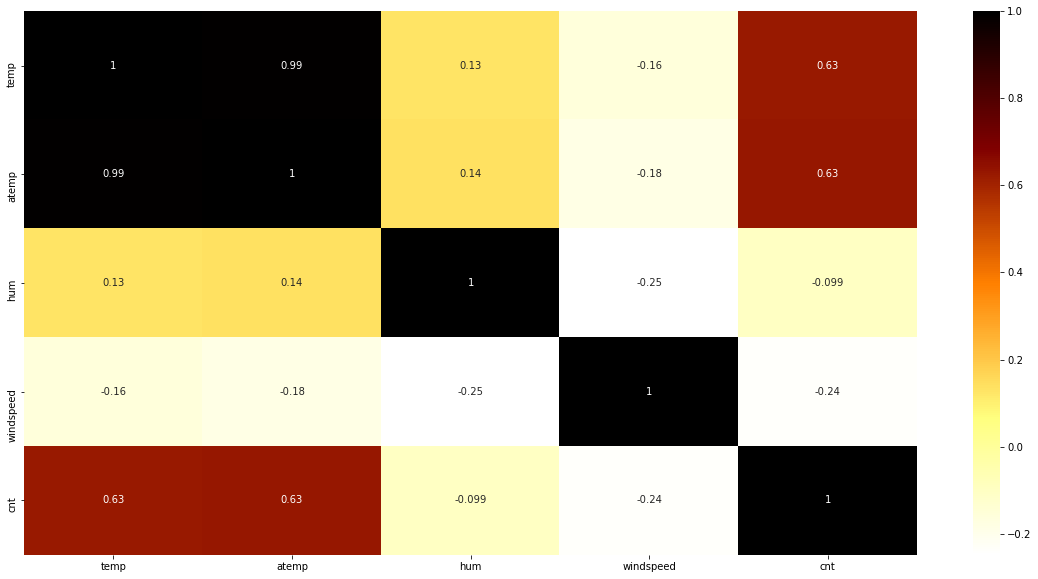

In [24]:
plt.figure(figsize = (20, 10))
sns.heatmap(boombikes_data_corr, annot = True, cmap="afmhot_r")
plt.show()

**Conclusion**

1. 'cnt' is highly positively correlated with 'atemp'.

2. 'cnt' is negatively correlated to 'windspeed' and 'hum' which means that demand for bikes are less duirng windy  and humidity days

3. atemp and temp are highly positively correlated 0.99 almost equal to 1. 

## 3. Creating Dummy Variables

In [25]:
### creating dummy variables for season , mnth ,weathersit ,weekday
dummy = boombikes_data[['season','mnth','weekday','weathersit']]

In [26]:
#Get the dummy variables for the categorical colns & store in dummies_df dataframe
dummies_bike= pd.get_dummies(dummy , drop_first = True )

In [27]:
## Concatinating dummy variables to original boombikes_data dataset
boombikes_data = pd.concat([boombikes_data,dummies_bike],axis = 1)

In [28]:
boombikes_data.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,...,mnth_Oct,mnth_Sep,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_Light_rainsnow,weathersit_Misty
0,Spring,0,Jan,0,Monday,1,Misty,14.110847,18.18125,80.5833,...,0,0,1,0,0,0,0,0,0,1
1,Spring,0,Jan,0,Tuesday,1,Misty,14.902598,17.68695,69.6087,...,0,0,0,0,0,0,1,0,0,1
2,Spring,0,Jan,0,Wednesday,1,Clear,8.050924,9.47025,43.7273,...,0,0,0,0,0,0,0,1,0,0
3,Spring,0,Jan,0,Thursday,1,Clear,8.200000,10.60610,59.0435,...,0,0,0,0,0,1,0,0,0,0
4,Spring,0,Jan,0,Friday,1,Clear,9.305237,11.46350,43.6957,...,0,0,0,0,0,0,0,0,0,0


In [29]:
boombikes_data.shape

(730, 34)

In [30]:
## dropping columns ['season', 'mnth', 'weekday','weathersit'] for which dummy variables were created
boombikes_data.drop(['season', 'mnth', 'weekday','weathersit'], axis = 1, inplace = True)

In [31]:
## Checking the head of dataset after dropping the dummy variables
boombikes_data.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_Spring,season_Summer,...,mnth_Oct,mnth_Sep,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_Light_rainsnow,weathersit_Misty
0,0,0,1,14.110847,18.18125,80.5833,10.749882,985.0,1,0,...,0,0,1,0,0,0,0,0,0,1
1,0,0,1,14.902598,17.68695,69.6087,16.652113,801.0,1,0,...,0,0,0,0,0,0,1,0,0,1
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349.0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562.0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600.0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
## Checking the shape of data
boombikes_data.shape

(730, 30)

## 4. Model building and Evaluation

In [33]:
#  first step for model building is test-train split
boombikes_train, boombikes_test = train_test_split(boombikes_data, train_size=0.7, test_size=0.3, random_state=100)
print(boombikes_train.shape)
print(boombikes_test.shape)

(510, 30)
(219, 30)


In [34]:
boombikes_train.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_Spring,season_Summer,...,mnth_Oct,mnth_Sep,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_Light_rainsnow,weathersit_Misty
653,1,0,1,19.201653,23.0423,55.8333,12.208807,7534.0,0,0,...,1,0,0,0,0,0,0,1,0,0
576,1,0,1,29.246653,33.1448,70.4167,11.083475,7216.0,0,0,...,0,0,0,0,0,0,0,1,0,0
426,1,0,0,16.980847,20.6746,62.1250,10.792293,4066.0,1,0,...,0,0,0,0,1,0,0,0,0,1
728,1,0,1,10.489153,11.5850,48.3333,23.500518,1796.0,1,0,...,0,0,1,0,0,0,0,0,0,0
482,1,0,0,15.443347,18.8752,48.9583,8.708325,4220.0,0,1,...,0,0,0,0,1,0,0,0,0,1


### Rescaling the features

For the easy interpretation of the data it is important to have all the variables on the same scale.

Two types of Scaling:

1. Minmaxscaler

2. Standardisation

In [35]:
scaler = MinMaxScaler()

In [36]:
# Apply scaler() to all the columns except the 'yes-no' and 'dummy' variables
boombikes_vars = ['temp', 'atemp', 'hum', 'windspeed' , 'cnt']

boombikes_train[boombikes_vars] = scaler.fit_transform(boombikes_train[boombikes_vars])

In [37]:
boombikes_train

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_Spring,season_Summer,...,mnth_Oct,mnth_Sep,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_Light_rainsnow,weathersit_Misty
653,1,0,1,0.509887,0.501133,0.575354,0.300794,0.864243,0,0,...,1,0,0,0,0,0,0,1,0,0
576,1,0,1,0.815169,0.766351,0.725633,0.264686,0.827658,0,0,...,0,0,0,0,0,0,0,1,0,0
426,1,0,0,0.442393,0.438975,0.640189,0.255342,0.465255,1,0,...,0,0,0,0,1,0,0,0,0,1
728,1,0,1,0.245101,0.200348,0.498067,0.663106,0.204096,1,0,...,0,0,1,0,0,0,0,0,0,0
482,1,0,0,0.395666,0.391735,0.504508,0.188475,0.482973,0,1,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,1,0,1,0.824514,0.762183,0.605840,0.355596,0.764151,0,1,...,0,0,0,0,0,0,1,0,0,1
578,1,0,1,0.863973,0.824359,0.679690,0.187140,0.832835,0,0,...,0,0,0,0,0,0,0,0,0,0
53,0,0,1,0.202618,0.218747,0.435939,0.111379,0.218017,1,0,...,0,0,0,0,0,0,0,0,0,0
350,0,0,1,0.248216,0.223544,0.577930,0.431816,0.312586,0,0,...,0,0,1,0,0,0,0,0,0,1


In [38]:
boombikes_train.describe()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_Spring,season_Summer,...,mnth_Oct,mnth_Sep,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_Light_rainsnow,weathersit_Misty
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,...,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.507843,0.025490,0.711765,0.537262,0.512989,0.650369,0.320768,0.513620,0.243137,0.245098,...,0.086275,0.080392,0.154902,0.129412,0.137255,0.143137,0.152941,0.135294,0.029412,0.343137
std,0.500429,0.157763,0.453386,0.225844,0.212385,0.145882,0.169797,0.224593,0.429398,0.430568,...,0.281045,0.272166,0.362166,0.335985,0.344454,0.350557,0.360284,0.342373,0.169124,0.475223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.339853,0.332086,0.538643,0.199179,0.356420,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.540519,0.526811,0.653714,0.296763,0.518638,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.735215,0.688457,0.754830,0.414447,0.684710,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


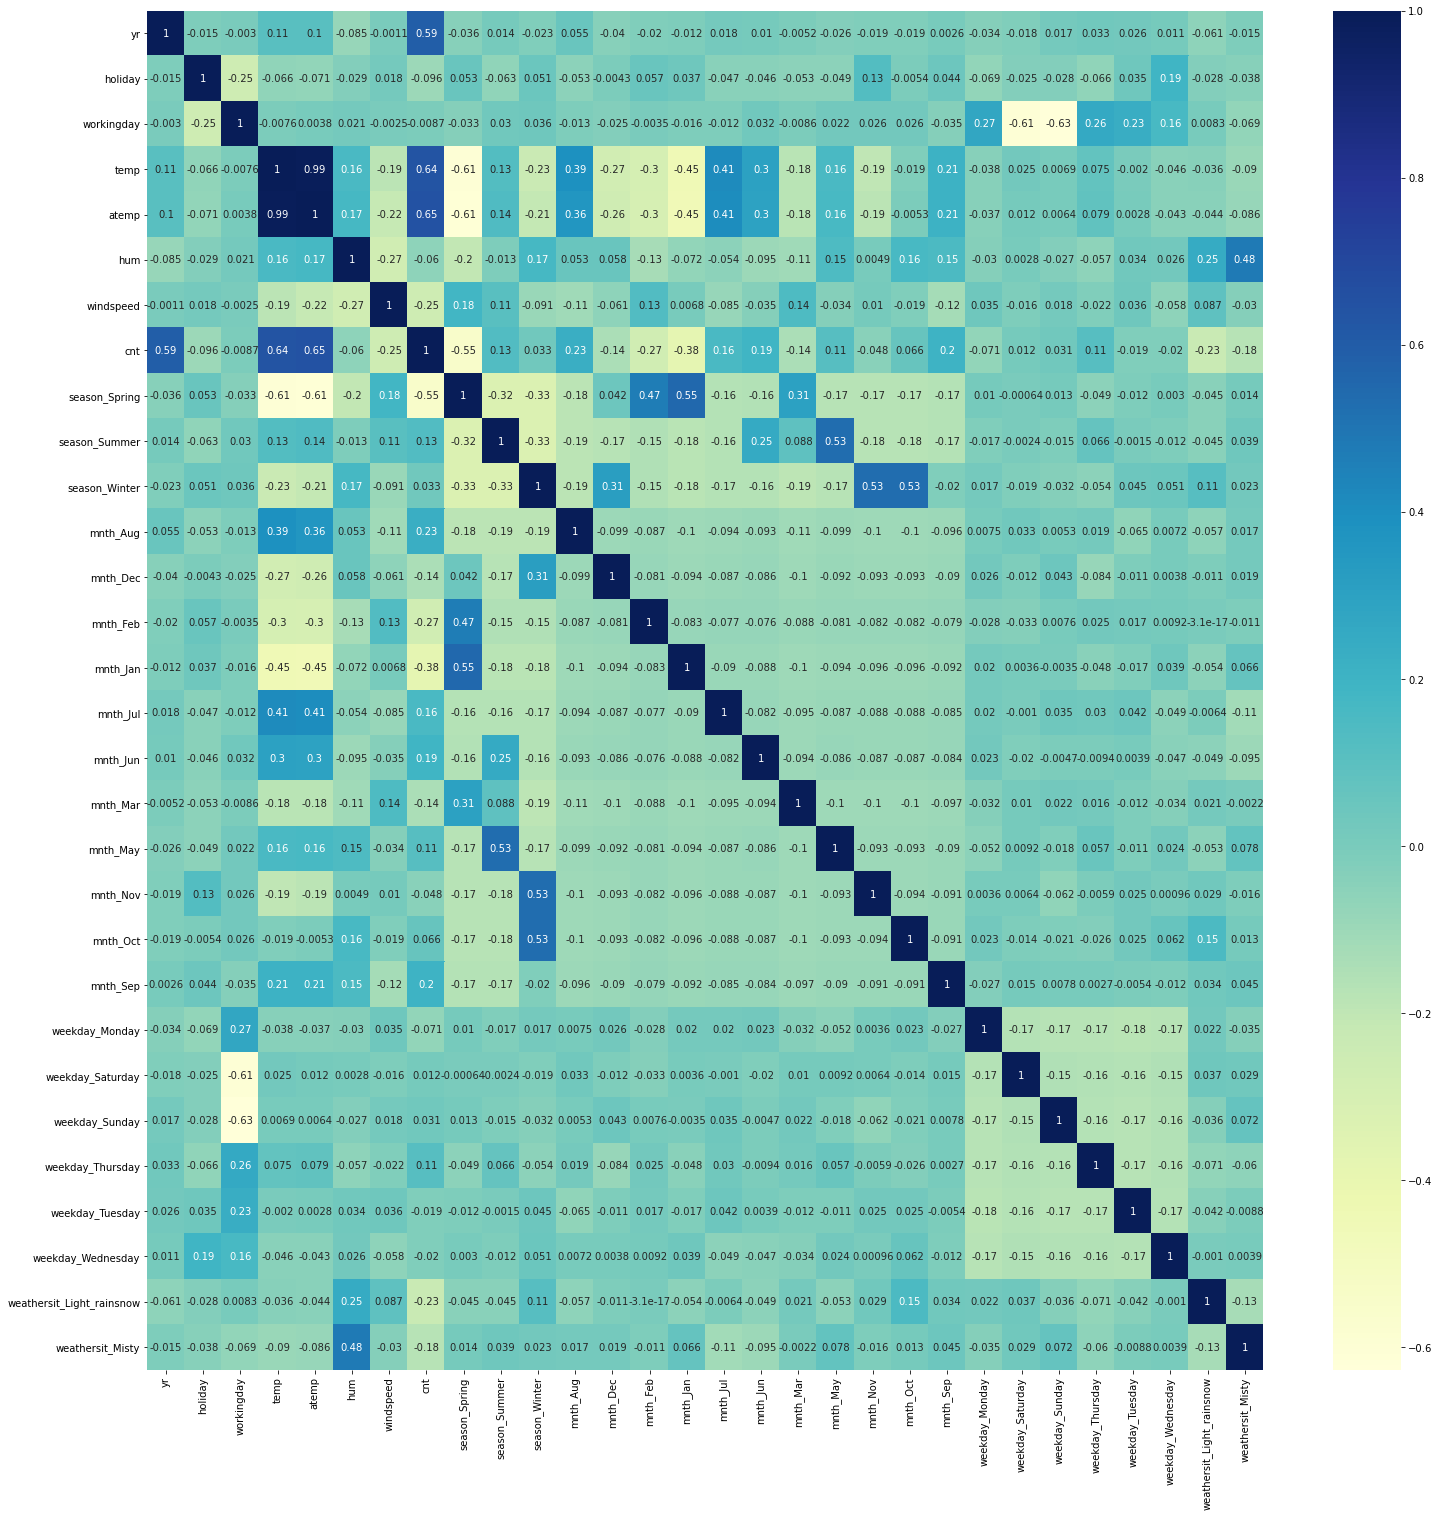

In [39]:
# Checking the correlation coefficients to find out which variables are highly correlated
plt.figure(figsize = (25, 25))
sns.heatmap(boombikes_train.corr(), annot = True, cmap="YlGnBu")
plt.show()

- 'atemp' and 'temp' variable seems to be correlated to 'cnt' variable the most

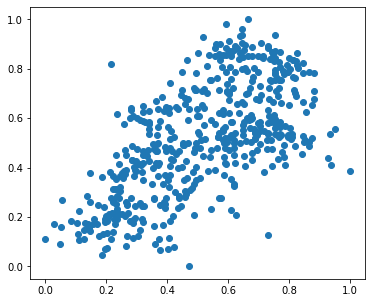

In [40]:
# using pairplot to see the correlation between atemp vs cnt
plt.figure(figsize=[6,5])
plt.scatter(boombikes_train.atemp, boombikes_train.cnt)
plt.show()

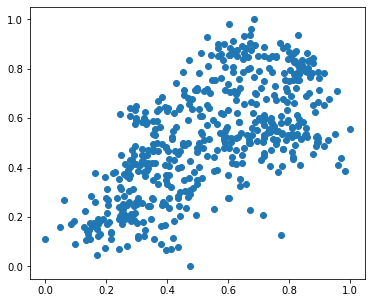

In [41]:
# using pairplot to see the correlation between atemp vs cnt
plt.figure(figsize=[6,5])
plt.scatter(boombikes_train.temp, boombikes_train.cnt)
plt.show()

In [42]:
##Dividing the data into x & y variable
y_train = boombikes_train.pop('cnt')
x_train = boombikes_train

In [43]:
x_train.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,season_Spring,season_Summer,season_Winter,...,mnth_Oct,mnth_Sep,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,weathersit_Light_rainsnow,weathersit_Misty
653,1,0,1,0.509887,0.501133,0.575354,0.300794,0,0,1,...,1,0,0,0,0,0,0,1,0,0
576,1,0,1,0.815169,0.766351,0.725633,0.264686,0,0,0,...,0,0,0,0,0,0,0,1,0,0
426,1,0,0,0.442393,0.438975,0.640189,0.255342,1,0,0,...,0,0,0,0,1,0,0,0,0,1
728,1,0,1,0.245101,0.200348,0.498067,0.663106,1,0,0,...,0,0,1,0,0,0,0,0,0,0
482,1,0,0,0.395666,0.391735,0.504508,0.188475,0,1,0,...,0,0,0,0,1,0,0,0,0,1


In [44]:
x_train.shape

(510, 29)

### Model Bulding using statsmodel

**Building Model based on all features**

In [45]:
# Adding constant
x_train_lm = sm.add_constant(x_train)

# Running the model
lr = sm.OLS(y_train, x_train_lm).fit()

# Checking the parameters
lr.params

const                        0.394765
yr                           0.230933
holiday                     -0.135245
workingday                  -0.060878
temp                         0.400268
atemp                        0.046419
hum                         -0.157757
windspeed                   -0.181137
season_Spring               -0.044097
season_Summer                0.041756
season_Winter                0.110482
mnth_Aug                     0.023034
mnth_Dec                    -0.045685
mnth_Feb                    -0.037177
mnth_Jan                    -0.063451
mnth_Jul                    -0.033912
mnth_Jun                     0.002144
mnth_Mar                     0.000805
mnth_May                     0.024765
mnth_Nov                    -0.041530
mnth_Oct                     0.005922
mnth_Sep                     0.086720
weekday_Monday              -0.024668
weekday_Saturday            -0.056309
weekday_Sunday              -0.050307
weekday_Thursday             0.003841
weekday_Tues

In [46]:
# Instantiate
lm = LinearRegression()

# Fit a line
lm.fit(x_train, y_train)


LinearRegression()

In [47]:
# Print the coefficients and intercept
print(lm.coef_)
print(lm.intercept_)

[ 0.23093281 -0.13524543 -0.06087771  0.4002683   0.04641884 -0.15775725
 -0.18113655 -0.04409727  0.04175634  0.11048189  0.02303422 -0.04568547
 -0.03717729 -0.06345092 -0.0339118   0.0021444   0.00080507  0.02476497
 -0.04152963  0.00592207  0.08671987 -0.02466808 -0.05630912 -0.05030733
  0.00384092 -0.02634096 -0.01124681 -0.25090187 -0.05931088]
0.39476468632954553


In [48]:
# Checking the model summary
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     94.48
Date:                Tue, 05 Jul 2022   Prob (F-statistic):          4.09e-178
Time:                        21:07:00   Log-Likelihood:                 523.87
No. Observations:                 510   AIC:                            -987.7
Df Residuals:                     480   BIC:                            -860.7
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

- Adjusted R-squared value of 84.2% which seems pretty good.

#### RFE- Recursive Feature Elimination

Since we have 29 features and manually one by one feature elimination is very hectic so RFE  is used to eliminate 
the features. We'll start with 13 shortlisted features and on that features statsmodel library will be used to find out the R2 and Adjusted R2.

In [49]:
# RFE with 15 features
lm = LinearRegression()
lm.fit(x_train, y_train)

rfe = RFE(lm, 15)
rfe = rfe.fit(x_train, y_train)

In [50]:
list(zip(x_train.columns,rfe.support_,rfe.ranking_))

[('yr', True, 1),
 ('holiday', True, 1),
 ('workingday', False, 3),
 ('temp', True, 1),
 ('atemp', False, 6),
 ('hum', True, 1),
 ('windspeed', True, 1),
 ('season_Spring', True, 1),
 ('season_Summer', True, 1),
 ('season_Winter', True, 1),
 ('mnth_Aug', False, 10),
 ('mnth_Dec', True, 1),
 ('mnth_Feb', False, 2),
 ('mnth_Jan', True, 1),
 ('mnth_Jul', True, 1),
 ('mnth_Jun', False, 14),
 ('mnth_Mar', False, 15),
 ('mnth_May', False, 7),
 ('mnth_Nov', True, 1),
 ('mnth_Oct', False, 12),
 ('mnth_Sep', True, 1),
 ('weekday_Monday', False, 9),
 ('weekday_Saturday', False, 4),
 ('weekday_Sunday', False, 5),
 ('weekday_Thursday', False, 13),
 ('weekday_Tuesday', False, 8),
 ('weekday_Wednesday', False, 11),
 ('weathersit_Light_rainsnow', True, 1),
 ('weathersit_Misty', True, 1)]

In [51]:
x_train_columns = x_train.columns[rfe.support_]
x_train_columns

Index(['yr', 'holiday', 'temp', 'hum', 'windspeed', 'season_Spring',
       'season_Summer', 'season_Winter', 'mnth_Dec', 'mnth_Jan', 'mnth_Jul',
       'mnth_Nov', 'mnth_Sep', 'weathersit_Light_rainsnow',
       'weathersit_Misty'],
      dtype='object')

In [52]:
x_train.columns[~rfe.support_]

Index(['workingday', 'atemp', 'mnth_Aug', 'mnth_Feb', 'mnth_Jun', 'mnth_Mar',
       'mnth_May', 'mnth_Oct', 'weekday_Monday', 'weekday_Saturday',
       'weekday_Sunday', 'weekday_Thursday', 'weekday_Tuesday',
       'weekday_Wednesday'],
      dtype='object')

### Model 1

**Building Model based on selected features and finding out the difference in all features adjusted R2 and 
after using RFE adjusted R2**

In [53]:
# Creating x_test dataframe with RFE selected variables
x_train_rfe1 = x_train[x_train_columns]

# Adding a constant variable 
 
x_train_rfe1 = sm.add_constant(x_train_rfe1)

# Running the linear model
lm = sm.OLS(y_train,x_train_rfe1).fit()  

# summary of linear model
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     180.2
Date:                Tue, 05 Jul 2022   Prob (F-statistic):          3.34e-189
Time:                        21:07:00   Log-Likelihood:                 514.72
No. Observations:                 510   AIC:                            -997.4
Df Residuals:                     494   BIC:                            -929.7
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [54]:
## Calculating the VIF for the new model
vif = pd.DataFrame()
x = x_train_rfe1.drop(['const'] , axis = 1)
vif['Features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,hum,30.94
2,temp,17.80
4,windspeed,4.72
5,season_Spring,4.37
7,season_Winter,4.06
6,season_Summer,2.81
14,weathersit_Misty,2.32
0,yr,2.09
11,mnth_Nov,1.83
9,mnth_Jan,1.75


### Model 2 

**Removing the "hum" variable becuase of its high VIF and low p-value**

In [55]:
x_train_m2=x_train_rfe1.drop(['hum'],axis=1)

In [56]:
x_train_m2.columns

Index(['const', 'yr', 'holiday', 'temp', 'windspeed', 'season_Spring',
       'season_Summer', 'season_Winter', 'mnth_Dec', 'mnth_Jan', 'mnth_Jul',
       'mnth_Nov', 'mnth_Sep', 'weathersit_Light_rainsnow',
       'weathersit_Misty'],
      dtype='object')

In [57]:
# Running the linear model
lm2 = sm.OLS(y_train,x_train_m2).fit()

# summary of our linear model
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     185.4
Date:                Tue, 05 Jul 2022   Prob (F-statistic):          1.57e-186
Time:                        21:07:00   Log-Likelihood:                 505.61
No. Observations:                 510   AIC:                            -981.2
Df Residuals:                     495   BIC:                            -917.7
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [58]:
# Calculate the VIF for the model 2 

vif = pd.DataFrame()
x = x_train_m2.drop(['const'] , axis = 1)
vif['Features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,temp,5.17
3,windspeed,4.67
6,season_Winter,2.94
4,season_Spring,2.89
5,season_Summer,2.23
0,yr,2.07
10,mnth_Nov,1.80
8,mnth_Jan,1.66
9,mnth_Jul,1.59
13,weathersit_Misty,1.56


### Model 3

**Removing season_Summer because of its high P-value and low VIF**

In [59]:
x_train_m3=x_train_m2.drop(['season_Summer'],axis=1)

In [60]:
x_train_m3.columns

Index(['const', 'yr', 'holiday', 'temp', 'windspeed', 'season_Spring',
       'season_Winter', 'mnth_Dec', 'mnth_Jan', 'mnth_Jul', 'mnth_Nov',
       'mnth_Sep', 'weathersit_Light_rainsnow', 'weathersit_Misty'],
      dtype='object')

In [61]:
# Running the linear model
lm3 = sm.OLS(y_train,x_train_m3).fit()

# summary of our linear model
print(lm3.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     197.9
Date:                Tue, 05 Jul 2022   Prob (F-statistic):          1.08e-186
Time:                        21:07:00   Log-Likelihood:                 503.24
No. Observations:                 510   AIC:                            -978.5
Df Residuals:                     496   BIC:                            -919.2
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [62]:
# Calculate the VIF for the model 3 

vif = pd.DataFrame()
x = x_train_m3.drop(['const'] , axis = 1)
vif['Features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,temp,4.67
3,windspeed,4.05
5,season_Winter,2.54
4,season_Spring,2.36
0,yr,2.06
9,mnth_Nov,1.80
7,mnth_Jan,1.65
12,weathersit_Misty,1.53
6,mnth_Dec,1.46
8,mnth_Jul,1.36


### Model 4

**Removing mnth_Dec because of its high P-value and low VIF**

In [63]:
x_train_m4=x_train_m3.drop(['mnth_Dec'],axis=1)

In [64]:
x_train_m4.columns

Index(['const', 'yr', 'holiday', 'temp', 'windspeed', 'season_Spring',
       'season_Winter', 'mnth_Jan', 'mnth_Jul', 'mnth_Nov', 'mnth_Sep',
       'weathersit_Light_rainsnow', 'weathersit_Misty'],
      dtype='object')

In [65]:
# Running the linear model
lm4 = sm.OLS(y_train,x_train_m4).fit()

# summary of our linear model
print(lm4.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     210.5
Date:                Tue, 05 Jul 2022   Prob (F-statistic):          4.86e-186
Time:                        21:07:01   Log-Likelihood:                 498.90
No. Observations:                 510   AIC:                            -971.8
Df Residuals:                     497   BIC:                            -916.8
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [66]:
# Calculate the VIF for the model 4

vif = pd.DataFrame()
x = x_train_m4.drop(['const'] , axis = 1)
vif['Features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,temp,4.65
3,windspeed,4.04
4,season_Spring,2.25
0,yr,2.06
5,season_Winter,1.92
6,mnth_Jan,1.60
8,mnth_Nov,1.59
11,weathersit_Misty,1.53
7,mnth_Jul,1.36
9,mnth_Sep,1.21


### Model 5

**Removing mnth_Nov because of its high P-value and low VIF**

In [67]:
x_train_m5=x_train_m4.drop(['mnth_Nov'],axis=1)

In [68]:
x_train_m5.columns

Index(['const', 'yr', 'holiday', 'temp', 'windspeed', 'season_Spring',
       'season_Winter', 'mnth_Jan', 'mnth_Jul', 'mnth_Sep',
       'weathersit_Light_rainsnow', 'weathersit_Misty'],
      dtype='object')

In [69]:
# Running the linear model
lm5 = sm.OLS(y_train,x_train_m5).fit()

# summary of our linear model
print(lm5.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     228.7
Date:                Tue, 05 Jul 2022   Prob (F-statistic):          1.13e-186
Time:                        21:07:01   Log-Likelihood:                 497.58
No. Observations:                 510   AIC:                            -971.2
Df Residuals:                     498   BIC:                            -920.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [70]:
# Calculate the VIF for the model 5

vif = pd.DataFrame()
x = x_train_m5.drop(['const'] , axis = 1)
vif['Features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,temp,4.63
3,windspeed,4.00
4,season_Spring,2.25
0,yr,2.06
6,mnth_Jan,1.60
10,weathersit_Misty,1.53
5,season_Winter,1.40
7,mnth_Jul,1.36
8,mnth_Sep,1.20
9,weathersit_Light_rainsnow,1.08


### Model 6

**Removing mnth_Jan because of its high P-value and low VIF**

In [71]:
x_train_m6=x_train_m5.drop(['mnth_Jan'],axis=1)

In [72]:
x_train_m6.columns

Index(['const', 'yr', 'holiday', 'temp', 'windspeed', 'season_Spring',
       'season_Winter', 'mnth_Jul', 'mnth_Sep', 'weathersit_Light_rainsnow',
       'weathersit_Misty'],
      dtype='object')

In [73]:
# Running the linear model
lm6 = sm.OLS(y_train,x_train_m6).fit()

# summary of our linear model
print(lm6.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     248.7
Date:                Tue, 05 Jul 2022   Prob (F-statistic):          1.16e-186
Time:                        21:07:01   Log-Likelihood:                 494.70
No. Observations:                 510   AIC:                            -967.4
Df Residuals:                     499   BIC:                            -920.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [74]:
# Calculate the VIF for the model 6

vif = pd.DataFrame()
x = x_train_m6.drop(['const'] , axis = 1)
vif['Features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,temp,4.60
3,windspeed,4.00
0,yr,2.06
4,season_Spring,1.65
9,weathersit_Misty,1.51
5,season_Winter,1.40
6,mnth_Jul,1.35
7,mnth_Sep,1.20
8,weathersit_Light_rainsnow,1.08
1,holiday,1.04


Now we can see we have our model.

The p values represents significance of the variables and VIF  represent correlation of variable with each other.

The VIFs and p-values both are within an acceptable range. So we go ahead and make our predictions using this model only.

## Residual Analysis

In [75]:
y_train_cnt = lm6.predict(x_train_m6)

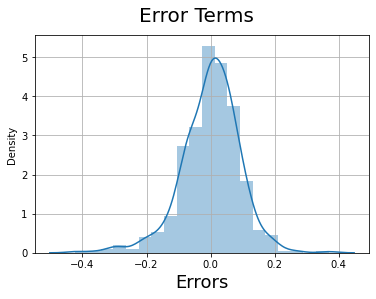

In [76]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((y_train - y_train_cnt), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                   
plt.xlabel('Errors', fontsize = 18) 
plt.grid()
plt.show()

We can see Error terms are normally distributed.

## 5. Making Predictions

In [77]:
# Scaling on the test sets
num_vars_test = ['temp', 'atemp', 'hum', 'windspeed' , 'cnt']

boombikes_test[num_vars_test] = scaler.transform(boombikes_test[num_vars_test])

In [78]:
y_test = boombikes_test.pop('cnt')
x_test = boombikes_test

In [79]:
# Building model to make predictions.

# Creating x_test1 dataframe by dropping variables from x_test
x_test_2 = x_test[x_train_m6.drop(['const'] , axis = 1).columns]

# Adding a constant variable 
x_test_2 = sm.add_constant(x_test_2)

In [80]:
y_pred = lm6.predict(x_test_2)

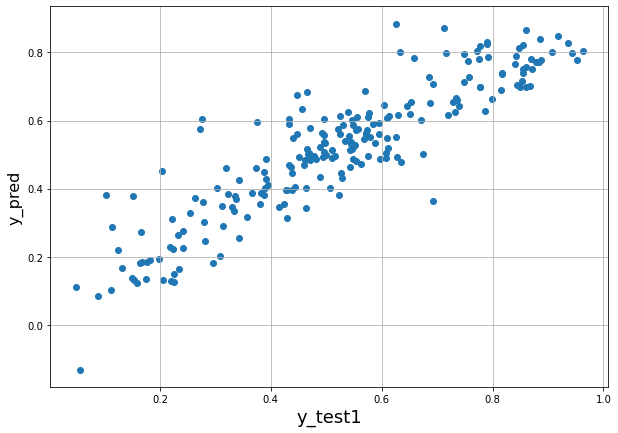

In [81]:
##  Model evaluation
plt.figure(figsize = [10,7])
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test1', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16)  

plt.grid()
plt.show()

In [82]:
# calculating R2
r2=round(r2_score(y_test, y_pred),4)
r2

0.807

In [83]:
# calculating adjusted R2 using formula: Adj R^2 = (1−(1−R^2)∗(n−1)/(n−p−1))

n = x_test.shape[0]    # No. of rows of test data
p =x_test.shape[1]    # No. of columns of test data

adjusted_r2 = round(1-(1-r2)*(n-1)/(n-p-1),4)
adjusted_r2

0.7774

### 6. Final step

In [84]:
final_result = pd.DataFrame(index=["Train data","Test data"])
final_result["r_square"]=[0.833,0.807] 
final_result["Adjusted_r_square"]=[0.830,0.7774]
final_result

,r_square,Adjusted_r_square
Train data,0.833,0.8300
Test data,0.807,0.7774


In [85]:
lm6.params

const                        0.251899
yr                           0.234092
holiday                     -0.098556
temp                         0.451455
windspeed                   -0.139817
season_Spring               -0.110795
season_Winter                0.047278
mnth_Jul                    -0.072719
mnth_Sep                     0.057705
weathersit_Light_rainsnow   -0.286408
weathersit_Misty            -0.081133
dtype: float64

## Equation for best fit line

cnt = yr x 0.234 + holiday x (-0.098) + temp x 0.451 + windspeed x (-0.139) + season_Spring x (-0.110) + season_Winter x 0.0472 + mnth_Jul x (-0.072) + mnth_Sep x 0.057 + weathersit_Light_rainsnow x (-0.286) + weathersit_Misty x(-0.081)



### Interpretation

1. This is the simplest model we can build

2. We can see that temperature variable is having the highest coefficient 0.047, which means if the temperature increases by one unit the number of bike rentals increases by 0.047 units.

3. we see coefficients of other variables in the equation for best fitted line.

4. We can observe there are some variables with negative coefficients, A negative coefficient suggests that as the independent variable increases, the dependent variable tends to decrease.
